In [3]:
import cv2
import numpy as np

In [5]:
empty_image = np.ones((400, 400, 3), dtype=np.uint8) * 255


# red circle
cv2.circle(empty_image, (200,75), 70, (0,0,255), thickness=-1) 
cv2.circle(empty_image, (200,75), 30, (255,255,255), thickness=-1)

# green circle
cv2.circle(empty_image, (125,205), 70, (0,255,0), thickness=-1)
cv2.circle(empty_image, (125,205), 30, (255,255,255), thickness=-1)

# blue circle
cv2.circle(empty_image, (275,205), 70, (255,0,0), thickness=-1)
cv2.circle(empty_image, (275,205), 30, (255,255,255), thickness=-1)

# white triangle 
triangle = np.array([[200,75],[125,205],[275,205]], np.int32)
triangle = triangle.reshape(3,1,2)
cv2.fillPoly(empty_image,[triangle],color=(255,255,255))

# blue circle re-draw
cv2.circle(empty_image, (275,205), 70, (255,0,0), thickness=-1)
cv2.circle(empty_image, (275,205), 30, (255,255,255), thickness=-1)
cv2.ellipse(empty_image, center=(275,205), axes=(70, 70), angle=0, startAngle=240,endAngle=300, color=(255,255,255), thickness=-1)

# OpenCV
cv2.putText(empty_image,'OpenCV',(125,325), cv2.FONT_HERSHEY_SIMPLEX, 1.25 , (0,0,0),4)

cv2.imshow('PART I: A photo booth application', empty_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [6]:
import cv2
import numpy as np

img1 = cv2.imread("123.jpg")
img2 = cv2.imread("airlineAnalysis.jpg")

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

cv2.imshow('test1', img1)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imshow('test2', img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

a = 0.5

blend = np.uint8((1 - a) * img1 + a * img2)



cv2.imshow("manual_blend.jpg", blend)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite("manual_blend.jpg", blend)


True

==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation
8. View History of Operations
9. Save and Exit
Padding (Choose border size)
1. Square
2. rectangle
3. Custom ratio
Padding has changed its reflect


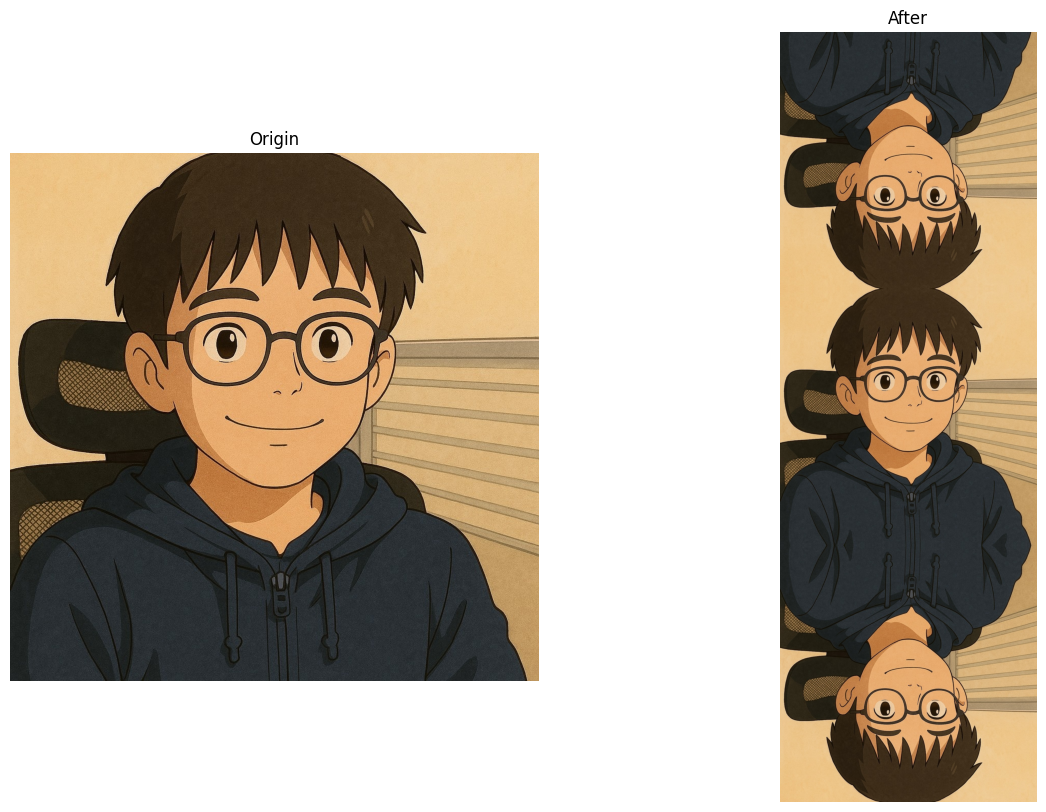

==== Mini Photo Editor ====
1. Adjust Brightness
2. Adjust Contrast
3. Convert to Grayscale
4. Add Padding (choose border type)
5. Apply Thresholding (binary or inverse)
6. Blend with Another Image (manual alpha)
7. Undo Last Operation
8. View History of Operations
9. Save and Exit


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:836: error: (-2:Unspecified error) could not find a writer for the specified extension in function 'cv::imwrite_'


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def menu():
    print("==== Mini Photo Editor ====")
    print("1. Adjust Brightness")
    print("2. Adjust Contrast")
    print("3. Convert to Grayscale")
    print("4. Add Padding (choose border type)")
    print("5. Apply Thresholding (binary or inverse)")
    print("6. Blend with Another Image (manual alpha)")
    print("7. Undo Last Operation")
    print("8. View History of Operations")
    print("9. Save and Exit")


def show_side_by_side(origin, after):
    plt.figure(figsize=(15,10))
    plt.subplot(1,2,1)
    plt.title("Origin")
    plt.axis('off')
    plt.imshow(cv2.cvtColor(origin, cv2.COLOR_BGR2RGB))
    plt.subplot(1,2,2)
    plt.title("After")
    plt.axis('off')
    plt.imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
    plt.show()



# For implement 7 and 8
history = []
history_log = []


def history_save(img, log):
    history.append(img.copy())
    history_log.append(log)

path_check = True
while path_check:
    file_path = input("Please input your image path(e.g. xxx.jpg, or C:/xxxx/xxx/image.jpg): ")
    img = cv2.imread(file_path)

    if img is None:
        print("No image or path is incorrect")
        path_check = True
    else:
        path_check = False


menu_check = True
while menu_check:
    menu()
    input_option = input("Please select the feature (1-9): ")

    if not input_option.isdigit():
        print("Please enter a valid number.")
        continue

    input_option = int(input_option)

    match input_option:
        case 1:
            origin = img.copy()
            input_brightness = input("Please input the number you want to adjust for brightness:")
            if not input_brightness.lstrip('-').isdigit():
                print("Invalid number.")
                continue
            else:
                input_brightness = int(input_brightness)
                if input_brightness > 0:
                    img = cv2.add(img, np.ones(img.shape, dtype=np.uint8) * input_brightness)
                elif input_brightness < 0:
                    img = cv2.subtract(img, np.ones(img.shape, dtype=np.uint8) * abs(input_brightness)) 
                else:
                    print("No change because you type 0. No compared img shown and back to menu.")
                    continue
            # add history function here
            history_save(img, f"Brightness adjusted by {input_brightness}")
            print(f"Brightness adjusted by {input_brightness}")
            show_side_by_side(origin, img)

        case 2:
            origin = img.copy()
            input_contrast = input("Please input the number you want to adjust for contrast: (Please input from decimal [e.g. 0.0, 1.5, 2.0...etc])")
            if not '.' in input_contrast: 
                print("Invalid number. No compared img shown and back to menu.")
                continue

            alpha = float(input_contrast)

            contrast_img = cv2.convertScaleAbs(img, alpha=alpha, beta=0)
            img = contrast_img
            # add history function here
            history_save(img, f"Contrast change by {input_contrast}")
            print(f"Contrast change by {input_contrast}")
            show_side_by_side(origin, img)
            
        case 3:
            origin = img.copy()
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img_gray
            history_save(img, "Gray image changed.")
            print(f"Gray image changed.")
            show_side_by_side(origin, img)
        
        case 4:
            origin = img.copy()
            print("Padding (Choose border size)")
            print("1. Square")
            print("2. rectangle")
            print("3. Custom ratio")
            input_padding = int(input("Please input the padding option: ")) # revise add int()

            # Default
            top = bottom = left = right = 0 # revise add int()
            
            match input_padding:
                case 1:
                    max_side = max(img.shape[0], img.shape[1]) # find the longer side, height or width
                    top = bottom = (max_side - img.shape[0]) // 2 # if top and bottom is shorter, padding should be added, and split evenly to the padding 
                    left = right = (max_side - img.shape[1]) // 2 # if left and right is shorter, padding should be added, and split evenly to the padding

                case 2:
                    top = bottom = 50
                    left = right = 50
                
                case 3:
                    input_ratio = input("Please the ratio(e.g. 4:5): ")
                    if not ':' in input_ratio:
                        print("Invalid format, you must have column symbol.")
                        continue
                    
                    ratio_parts = input_ratio.split(":")
                    first_part = int(ratio_parts[0])
                    second_part = int(ratio_parts[1])
                    
                    current_height, current_weight = img.shape[:2]
                    current_img_ratio = current_height / current_weight
                    target_img_ratio = first_part / second_part

                    # need padding to left and right
                    if current_img_ratio < target_img_ratio:
                        target_width = int(current_height * target_img_ratio)
                        pad_total = target_width - current_weight
                        
                        left = right = pad_total // 2
                        top = bottom = 0
                    
                    # need padding to top and bottom
                    elif current_img_ratio > target_img_ratio:
                        target_height = int(current_weight / target_img_ratio)
                        pad_total = target_height - current_weight
                        top = bottom = pad_total // 2
                        left = right = 0
                    else:
                        top = bottom = left = right
            borderType_check = True
            while borderType_check:
                input_borderType = input("Please input the border type: (constant, reflect, replicate)")
                if input_borderType == 'constant':
                    input_color = input("Please input the color by B G R from 0 to 255(e.g. 255,255,255)")
                    r, g, b = map(int, input_color.strip().split(',')) # tuple
                    color = [b, g, r] 
                    borderType = cv2.BORDER_CONSTANT
                    borderType_check = False
                elif input_borderType == 'reflect':
                    borderType = cv2.BORDER_REFLECT
                    borderType_check = False
                elif input_borderType == 'replicate':
                    borderType = cv2.BORDER_REPLICATE
                    borderType_check = False
                else:
                    print("Invalid border Type.")
                    borderType_check = True
            
            if borderType == cv2.BORDER_CONSTANT:
                
                padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType, value=color) # update color, haven't test if it's correct
            else:
                padded_img = cv2.copyMakeBorder(img, top, bottom, left, right, borderType)


            img = padded_img
            # add history function here
            history_save(img, f"Padding has changed its {input_borderType}")
            print(f"Padding has changed its {input_borderType}")
            show_side_by_side(origin, img)
        case 5:
            origin = img.copy()
            input_mode = input("Choose mode (binary / binary_inv): ").strip()
            if input_mode == "binary":
                thresh_type = cv2.THRESH_BINARY
            elif input_mode == "binary_inv":
                thresh_type = cv2.THRESH_BINARY_INV
            
            else:
                print("Invalid mode.")
                continue

            history_save(img, f"Threshold applied with mode: {input_mode}")
            _, img = cv2.threshold(img,127,255,thresh_type)
            show_side_by_side(origin, img)
        
        case 6:
            origin = img.copy()
            path_check2 = True
            while path_check2:
                file_path2 = input("Please input your image path(e.g. xxx.jpg, or C:/xxxx/xxx/image.jpg): ")
                img2 = cv2.imread(file_path2)

            if img2 is None:
                print("No image or path is incorrect")
                path_check2 = True
            else:
                path_check2 = False

            img2 = cv2.resize(img2, (img.shape[1], img.shape[0]))
            input_alpha = input("Please input alpha value from 0 to 1(e.g. 0.5): ")

            if not '.' in input_alpha:
                print("Invalid format, you must have column symbol.")
                continue
            
            alpha = float(input_alpha)

            img_blend = cv2.addWeighted(img, alpha, img2, alpha)
            img = img_blend
            history_save(img, f"{file_path2} of the second image has blended into img 1")
            print(f"{file_path2} of the second image has blended into img 1")
            show_side_by_side(origin, img)
            
        case 7:
            if history:
                img = history.pop()
                action = history_log.pop()
                print(f"Undo last operation: {action}")
            
            else:
                print("No undo operation.")
        
        case 8:
            if history_log:
                print("History log")
                for i, action in range(history_log):
                    print(f"{i}. {action}")
            else:
                print("No history")
        
        case 9:
            output_img_name= input("Please enter the filename to save(e.g. xxx.png): ")
            cv2.imwrite(output_img_name, img)
            print(f"Image saved {output_img_name}. Good bye~")
            break




                    
            

